# Volatility — cross-model evaluation

Pulls together the per-model outputs written by `01`–`04` and compares them on a common
footing.

| Model | Notebook | Features |
|---|---|---|
| Naïve | `01_har` | $\text{RV}_{t-1}$ |
| HAR-RV | `01_har` | 3 HAR lags |
| GARCH(1,1) | `02_garch` | weekly returns (parametric) |
| Random Forest | `03_random_forest` | HAR + EXOG |
| XGBoost | `04_xgboost` | HAR + EXOG |

Run `00`–`04` first so their `metrics_*` / `pred_*` / `period_*` CSVs are fresh.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vol_utils import vol_diebold_mariano
import warnings; warnings.filterwarnings('ignore')

PROC   = '../../data/processed'
MODELS = ['har', 'garch', 'rf', 'xgb']

metrics = pd.concat([pd.read_csv(f'{PROC}/metrics_{m}_volatility.csv') for m in MODELS],
                    ignore_index=True)
preds   = {m: pd.read_csv(f'{PROC}/pred_{m}_volatility.csv',
                          parse_dates=['Date']).set_index('Date') for m in MODELS}
print('loaded', len(metrics), 'metric rows from', len(MODELS), 'notebooks')

loaded 5 metric rows from 4 notebooks


## 1. Combined results table

All models on RMSE / MAE / $R^2$ / DCA, sorted by RMSE (lower is better). Saved to
`metrics_volatility_summary.csv`.


In [2]:
metrics_sorted = metrics.sort_values('rmse').reset_index(drop=True)
metrics_sorted.to_csv(f'{PROC}/metrics_volatility_summary.csv', index=False)
metrics_sorted.round(5)


,model,rmse,mae,r2,dca
0,HAR-RV,0.03153,0.01576,0.31255,0.71429
1,"GARCH(1,1)",0.03296,0.01824,0.24899,0.67429
2,RF (HAR+EXOG),0.03518,0.01832,0.14460,0.68000
3,XGB (HAR+EXOG),0.03702,0.01970,0.05242,0.69714
4,Naive (RV_t-1),0.03979,0.02013,-0.09462,0.00000


## 2. Sub-period breakdown

Per-year RMSE and DCA for each model (Naïve excluded — it has no `period_*` file of its
own). Saved to `period_volatility_summary.csv`.


In [3]:
period_all = []
for m in MODELS:
    p = pd.read_csv(f'{PROC}/period_{m}_volatility.csv')
    p.insert(0, 'model', m.upper())
    period_all.append(p)
period_all = pd.concat(period_all, ignore_index=True)
period_all.to_csv(f'{PROC}/period_volatility_summary.csv', index=False)
period_all.round(4)


,model,Period,n,RMSE,DCA
0,HAR,2023 (choppy),52,0.0148,0.6923
1,HAR,2024 (bull start),52,0.0145,0.7885
2,HAR,2025 (bull run),52,0.0222,0.6923
3,HAR,2026 (YTD),19,0.0815,0.6316
4,HAR,── Full test ──,175,0.0315,0.7143
5,GARCH,2023 (choppy),52,0.0162,0.6731
6,GARCH,2024 (bull start),52,0.0145,0.7885
7,GARCH,2025 (bull run),52,0.0251,0.6346
8,GARCH,2026 (YTD),19,0.0836,0.4737
9,GARCH,── Full test ──,175,0.0330,0.6743


## 3. 2026 zoom — actual vs each model

Same 2026 sanity-check view as the return notebooks: actual RV in black, each model
overlaid.


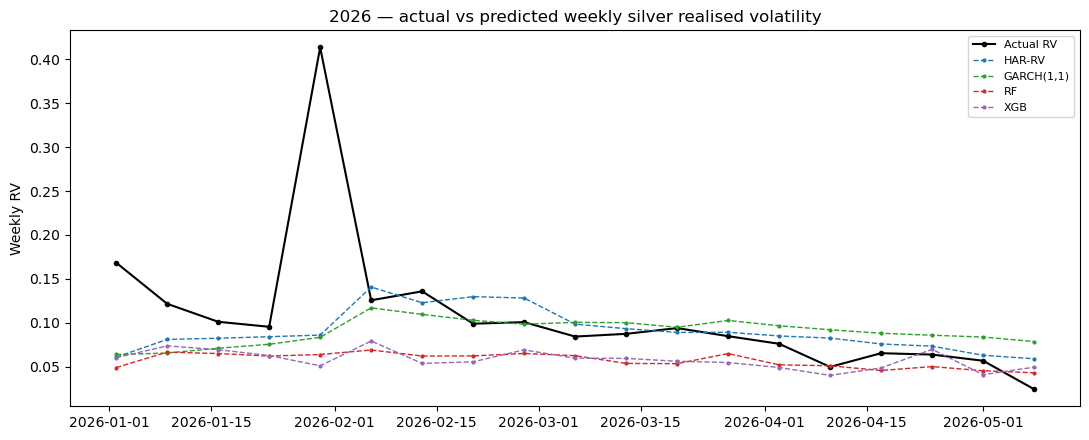

In [4]:
zoom = preds['har'][['actual']].copy()
zoom['Naive']      = preds['har']['naive']
zoom['HAR-RV']     = preds['har']['har']
zoom['GARCH(1,1)'] = preds['garch']['garch']
zoom['RF']         = preds['rf']['rf']
zoom['XGB']        = preds['xgb']['xgb']
zoom = zoom.loc['2026-01-01':]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(zoom.index, zoom['actual'], 'k-', lw=1.5, marker='o', ms=3, label='Actual RV')
for col, c in zip(['HAR-RV', 'GARCH(1,1)', 'RF', 'XGB'],
                  ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']):
    ax.plot(zoom.index, zoom[col], '--', lw=1, marker='.', ms=4, color=c, label=col)
ax.set_title('2026 — actual vs predicted weekly silver realised volatility')
ax.set_ylabel('Weekly RV'); ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


## 4. Diebold-Mariano tests

Each model against the Naïve floor — Newey-West lag-1 variance, via `vol_diebold_mariano`
in `vol_utils`. A negative DM stat means the model has lower loss; the stars show
whether the gap is significant. Naïve is the baseline because it is the smallest
possible model.

**The loss function matters here.** Weekly silver RV is extremely heavy-tailed — the
2026 spike weeks carry RV roughly 10× the median. Under **squared-error** loss a single
extreme week can account for ~80 % of the loss differential, which inflates the DM
variance and destroys the test's power even when a model's RMSE is clearly lower. The
volatility-forecasting literature (Patton 2011) therefore compares forecasts under
**QLIKE** — a proxy-robust, ratio-based loss that is far less sensitive to extreme
weeks. QLIKE-DM is reported as the **primary** test below; squared-error DM is kept
underneath as a reference.

The gap between the two is itself informative: a model can be steadily and
significantly better in normal weeks (QLIKE-significant) yet not separable under MSE,
because in the handful of extreme weeks *every* model is about equally wrong.

In [5]:
actual = preds['har']['actual'].values
naive  = preds['har']['naive'].values
model_preds = {'HAR-RV':     preds['har']['har'].values,
               'GARCH(1,1)': preds['garch']['garch'].values,
               'RF':         preds['rf']['rf'].values,
               'XGB':        preds['xgb']['xgb'].values}

dm_rows = []
print('QLIKE loss  --  primary test, robust to the extreme RV weeks:')
for name, p in model_preds.items():
    dm_rows.append(vol_diebold_mariano(actual, p, naive, name, 'Naive', loss='qlike'))

print('\nSquared-error loss  --  reference, dominated by a few tail weeks:')
for name, p in model_preds.items():
    dm_rows.append(vol_diebold_mariano(actual, p, naive, name, 'Naive', loss='mse'))

pd.DataFrame(dm_rows).to_csv(f'{PROC}/dm_volatility_summary.csv', index=False)

QLIKE loss  --  primary test, robust to the extreme RV weeks:
HAR-RV       vs Naive         [qlike]  DM=-2.820  p=0.005  **
GARCH(1,1)   vs Naive         [qlike]  DM=-2.594  p=0.009  **
RF           vs Naive         [qlike]  DM=-1.309  p=0.190  (ns)
XGB          vs Naive         [qlike]  DM=-0.006  p=0.995  (ns)

Squared-error loss  --  reference, dominated by a few tail weeks:
HAR-RV       vs Naive         [mse  ]  DM=-1.348  p=0.178  (ns)
GARCH(1,1)   vs Naive         [mse  ]  DM=-1.161  p=0.246  (ns)
RF           vs Naive         [mse  ]  DM=-1.141  p=0.254  (ns)
XGB          vs Naive         [mse  ]  DM=-0.884  p=0.377  (ns)


## 5. Conclusion

Read the tables above against these questions:

1. **Does HAR-RV beat Naïve on RMSE?** If yes, silver volatility has predictable
   structure beyond a pure random walk — consistent with the equity/FX literature.
2. **Does GARCH(1,1) beat HAR-RV?** On weekly equity-like series HAR usually wins;
   GARCH is parametric and assumes Gaussian innovations.
3. **Do the EXOG cross-asset RVs help?** RF/XGB vs HAR-RV — if the trees with EXOG beat
   HAR, that is evidence of volatility spillover across asset classes, and the feature
   importance plots in `03`/`04` show *which* cross-asset RVs carry the signal.
4. **DCA** — vol rising vs falling is the trader-relevant binary. DCA > 0.55 is already
   useful for risk-management timing. (The Naïve DCA is ≈ 0 by construction: predicting
   last week's RV implies *no* change, so it can never call a direction.)
5. **Statistical significance** — read the **QLIKE-DM** row, not the squared-error row.
   Squared-error DM is near-powerless on this heavy-tailed RV target (one 2026 week
   carries ~80 % of the loss differential), so an RMSE improvement that is real and
   steady can still fail an MSE-DM test. QLIKE — the proxy-robust loss standard in the
   volatility literature — is the test to report; MSE-DM is kept only as a reference
   that demonstrates the heavy-tail problem.

If volatility turns out to be substantially more forecastable than direction — which
the ACF plot in `00_features` already hints at — this chapter stands on its own:
predicting *when* silver moves rather than *which way*. Risk management, options
pricing and position sizing all consume volatility forecasts, so that is a defensible
thesis contribution even though weekly return direction is only weakly predictable.